# Phase 2: Regime Detection

**Goal:** Fit a GaussianHMM on train-period features (2000–2017) to discover macro regimes, then apply the frozen model across the full 2000–2023 dataset to produce `regime_label` for every trading day.

**Inputs:** `data/raw/master.csv`  
**Outputs:** Updated `data/raw/master.csv` (with `regime_label` column) + 4 visualizations

**Anti-lookahead rules:**
- `StandardScaler` fit on train rows only
- `GaussianHMM.fit()` called on train rows only
- `model.predict()` on full dataset is valid — frozen model applied forward

## 0. Imports & Config

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from src.hmm_model import train_hmm, select_n_regimes, get_viterbi_path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='darkgrid')

DATA_RAW = Path('../data/raw')
FIGURES  = Path('../results/figures')
RESULTS  = Path('../results')

TRAIN_END = '2017-12-31'

REGIME_COLORS = {0: '#90EE90', 1: '#FF6B6B', 2: '#FFD700', 3: '#87CEEB'}

FEATURE_COLS = ['realized_vol_20d', 'yield_spread', 'vix']

print('Setup complete.')

Setup complete.


## 1. Load Data & Prepare Features

In [2]:
df = pd.read_csv(DATA_RAW / 'master.csv', index_col=0, parse_dates=True)
print(f'Loaded: {df.shape[0]:,} rows | {df.index.min().date()} → {df.index.max().date()}')

train_mask = df.index <= TRAIN_END
print(f'Train rows: {train_mask.sum():,} | Val+Test rows: {(~train_mask).sum():,}')

Loaded: 6,017 rows | 2000-02-01 → 2023-12-29
Train rows: 4,508 | Val+Test rows: 1,509


In [3]:
# Fit scaler on train only, transform full dataset
scaler = StandardScaler()
train_features = df.loc[train_mask, FEATURE_COLS].values
all_features = df[FEATURE_COLS].values

scaler.fit(train_features)
train_scaled = scaler.transform(train_features)
all_scaled   = scaler.transform(all_features)

print('Train feature stats (should be ~0 mean, ~1 std):')
print(pd.DataFrame(train_scaled, columns=FEATURE_COLS).describe().loc[['mean','std']].round(3))

Train feature stats (should be ~0 mean, ~1 std):
      realized_vol_20d  yield_spread  vix
mean              -0.0           0.0  0.0
std                1.0           1.0  1.0


## 2. BIC Model Selection (K = 2–5)

In [4]:
best_k, bic_scores = select_n_regimes(train_scaled, k_range=range(2, 6))

print('BIC scores:')
for k, bic in sorted(bic_scores.items()):
    marker = ' ← optimal' if k == best_k else ''
    print(f'  K={k}: {bic:,.1f}{marker}')

BIC scores:
  K=2: 98,522,891.6
  K=3: 101,853,332.1
  K=4: 63,994,680.1 ← optimal
  K=5: 65,612,770.7


## 3. Fit Optimal HMM & Extract Viterbi Path

In [5]:
# Fit on train only
model = train_hmm(train_scaled, best_k)
print(f'Fitted GaussianHMM with K={best_k}')
print(f'Log-likelihood (train): {model.score(train_scaled):.4f}')

# Apply frozen model to full dataset
regime_labels = get_viterbi_path(model, all_scaled)
df['regime_label'] = regime_labels

print('\nRegime distribution (full dataset):')
print(df['regime_label'].value_counts().sort_index())

Fitted GaussianHMM with K=4
Log-likelihood (train): -7097.8567

Regime distribution (full dataset):
regime_label
0    1654
1     638
2    2176
3    1549
Name: count, dtype: int64


In [6]:
# Save updated master.csv with regime_label column
df.to_csv(DATA_RAW / 'master.csv')
print('Saved updated master.csv with regime_label column.')

# Persist scaler and model for downstream phases
RESULTS.mkdir(parents=True, exist_ok=True)
with open(RESULTS / 'hmm_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(RESULTS / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved hmm_model.pkl and feature_scaler.pkl to results/.')

Saved updated master.csv with regime_label column.
Saved hmm_model.pkl and feature_scaler.pkl to results/.


## 4. Visualizations

### VIZ 2.1 — BIC Curve

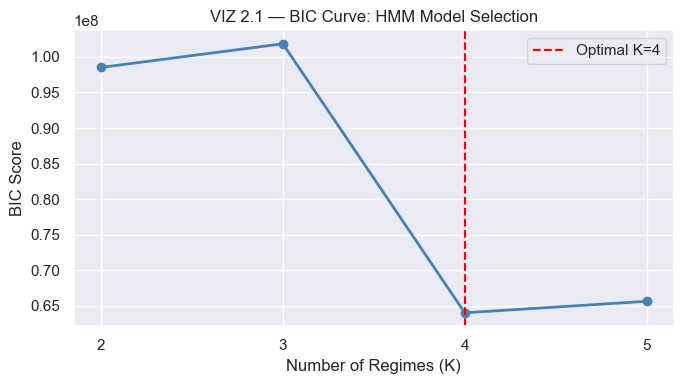

In [7]:
ks   = sorted(bic_scores.keys())
bics = [bic_scores[k] for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, bics, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Optimal K={best_k}')
ax.set_xlabel('Number of Regimes (K)')
ax.set_ylabel('BIC Score')
ax.set_title('VIZ 2.1 — BIC Curve: HMM Model Selection')
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / 'viz_2_1_bic_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 2.2 — Regime Timeline (Most Critical Plot)

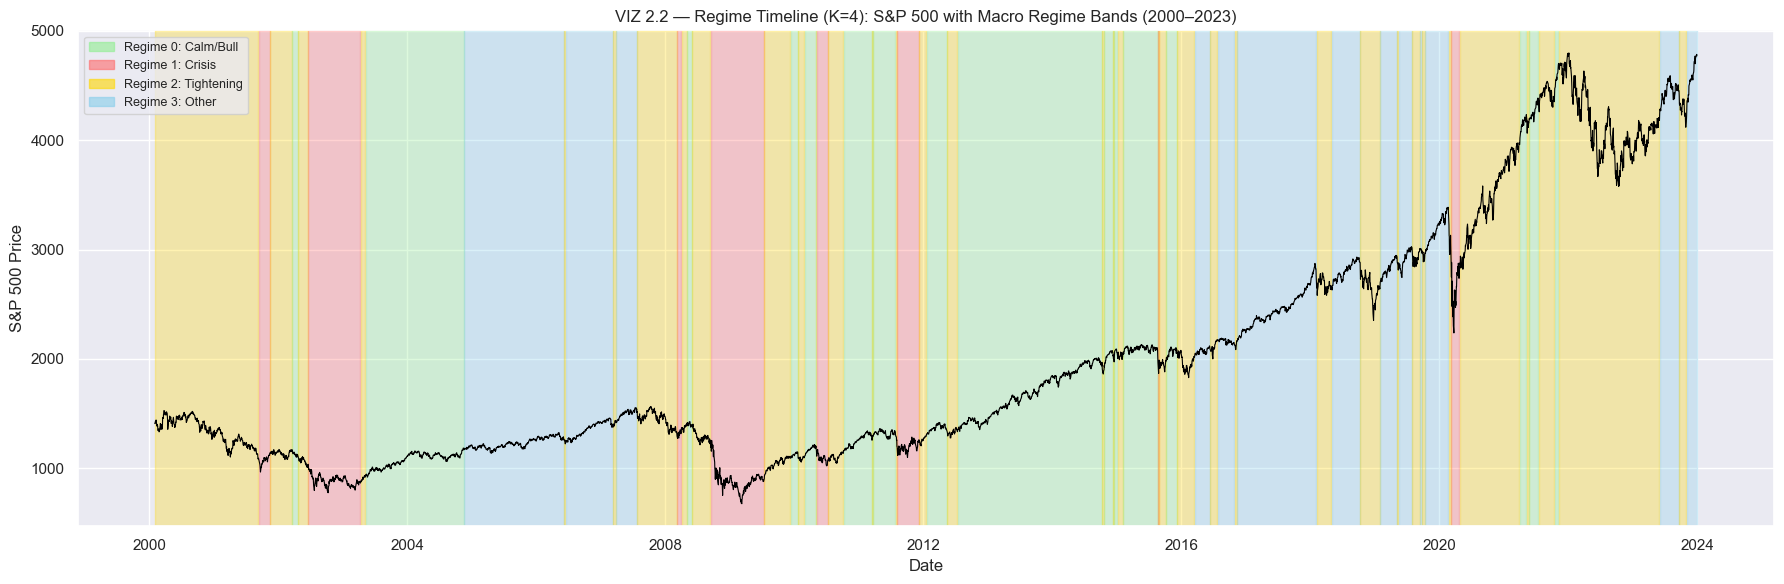

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))

# Plot S&P 500 price
ax.plot(df.index, df['gspc'], color='black', linewidth=0.8, zorder=3)

# Color background by regime using contiguous spans
labels = df['regime_label'].values
dates  = df.index
i = 0
while i < len(labels):
    j = i
    while j < len(labels) and labels[j] == labels[i]:
        j += 1
    ax.axvspan(dates[i], dates[j - 1], alpha=0.3,
               color=REGIME_COLORS.get(labels[i], '#CCCCCC'), zorder=1)
    i = j

# Legend
regime_names = {0: 'Calm/Bull', 1: 'Crisis', 2: 'Tightening', 3: 'Other'}
patches = [
    mpatches.Patch(color=REGIME_COLORS[r], alpha=0.6, label=f'Regime {r}: {regime_names.get(r, "")}')
    for r in sorted(REGIME_COLORS.keys()) if r < best_k
]
ax.legend(handles=patches, loc='upper left', fontsize=9)

ax.set_ylabel('S&P 500 Price')
ax.set_title(f'VIZ 2.2 — Regime Timeline (K={best_k}): S&P 500 with Macro Regime Bands (2000–2023)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGURES / 'viz_2_2_regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 2.3 — Feature Distributions Per Regime

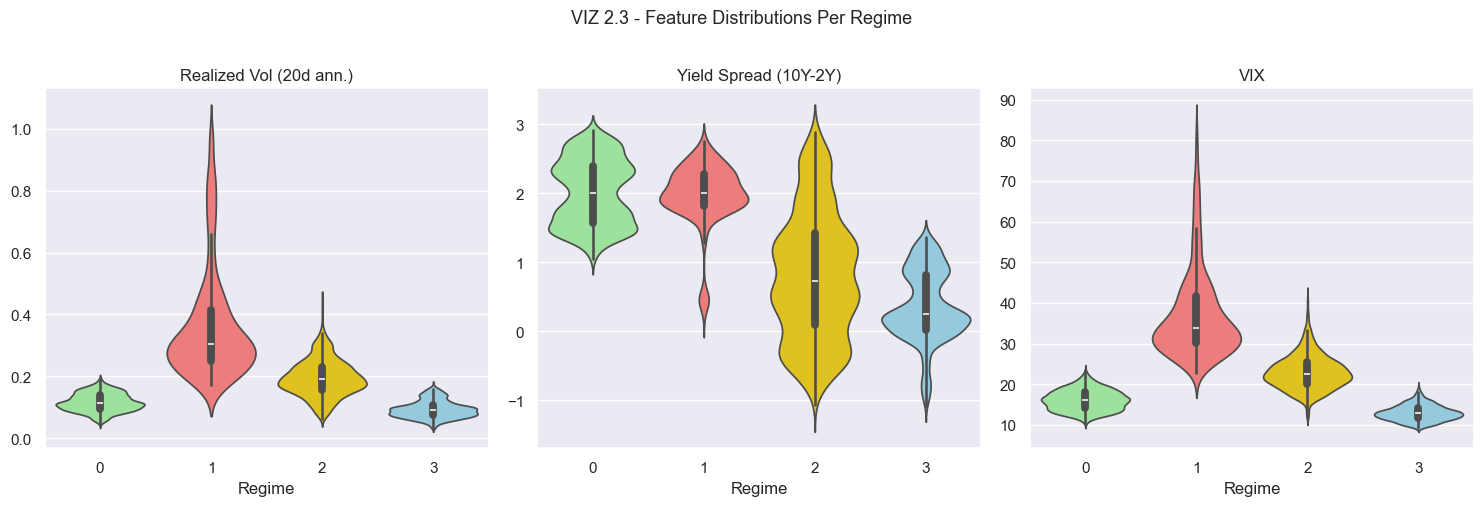

In [9]:
feature_labels = {'realized_vol_20d': 'Realized Vol (20d ann.)',
                  'yield_spread':     'Yield Spread (10Y-2Y)',
                  'vix':              'VIX'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, FEATURE_COLS):
    plot_df = df[['regime_label', col]].copy()
    # Seaborn converts integer x-values to strings for categorical axis
    palette = {str(r): REGIME_COLORS[r] for r in range(best_k)}
    sns.violinplot(data=plot_df, x='regime_label', y=col,
                   palette=palette, ax=ax, inner='box')
    ax.set_title(feature_labels[col])
    ax.set_xlabel('Regime')
    ax.set_ylabel('')

fig.suptitle('VIZ 2.3 - Feature Distributions Per Regime', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'viz_2_3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 2.4 — Transition Matrix Heatmap

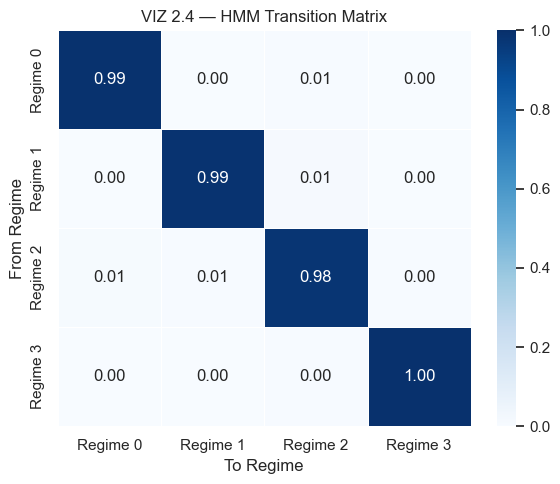


Transition matrix diagonal (regime stability):
  Regime 0: 0.992 ✓
  Regime 1: 0.988 ✓
  Regime 2: 0.980 ✓
  Regime 3: 0.995 ✓


In [10]:
transmat = model.transmat_
regime_labels_list = [f'Regime {i}' for i in range(best_k)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(transmat, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=regime_labels_list,
            yticklabels=regime_labels_list,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('VIZ 2.4 — HMM Transition Matrix')
ax.set_xlabel('To Regime')
ax.set_ylabel('From Regime')
plt.tight_layout()
plt.savefig(FIGURES / 'viz_2_4_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTransition matrix diagonal (regime stability):')
for i, p in enumerate(transmat.diagonal()):
    status = '✓' if p > 0.90 else '✗ BELOW THRESHOLD'
    print(f'  Regime {i}: {p:.3f} {status}')

## 5. Phase 2 Gate Checks

In [11]:
# Gate: transition matrix diagonal > 0.90
min_diag = model.transmat_.diagonal().min()
assert min_diag > 0.90, f'FAIL: regime not stable — min diagonal = {min_diag:.3f} (need >0.90)'

# Gate: regime_label column present
assert 'regime_label' in df.columns, 'FAIL: regime_label column missing'

# Gate: correct number of unique regimes
assert df['regime_label'].nunique() == best_k, f'FAIL: expected {best_k} regimes'

# Gate: no missing regime labels
assert df['regime_label'].isnull().sum() == 0, 'FAIL: missing regime labels'

# Gate: master.csv still has zero NaNs in core columns
assert df[['sp500_return','realized_vol_20d','vix','yield_spread']].isnull().sum().sum() == 0

print(f'All Phase 2 gate checks PASSED.')
print(f'Optimal K={best_k} | Min transition diagonal={min_diag:.3f}')
print(f'Regime distribution:')
print(df['regime_label'].value_counts().sort_index().to_string())

All Phase 2 gate checks PASSED.
Optimal K=4 | Min transition diagonal=0.980
Regime distribution:
regime_label
0    1654
1     638
2    2176
3    1549
